Mapped 'benign' to 0 and 'malignant' to 1 for the target variable.
Data loaded from /content/breastcancer.csv. Features shape: (683, 10), Target shape: (683,)
Dataset Shape: (683, 10)

Decision Tree Accuracy:
0.9416058394160584

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        79
           1       0.98      0.88      0.93        58

    accuracy                           0.94       137
   macro avg       0.95      0.93      0.94       137
weighted avg       0.94      0.94      0.94       137



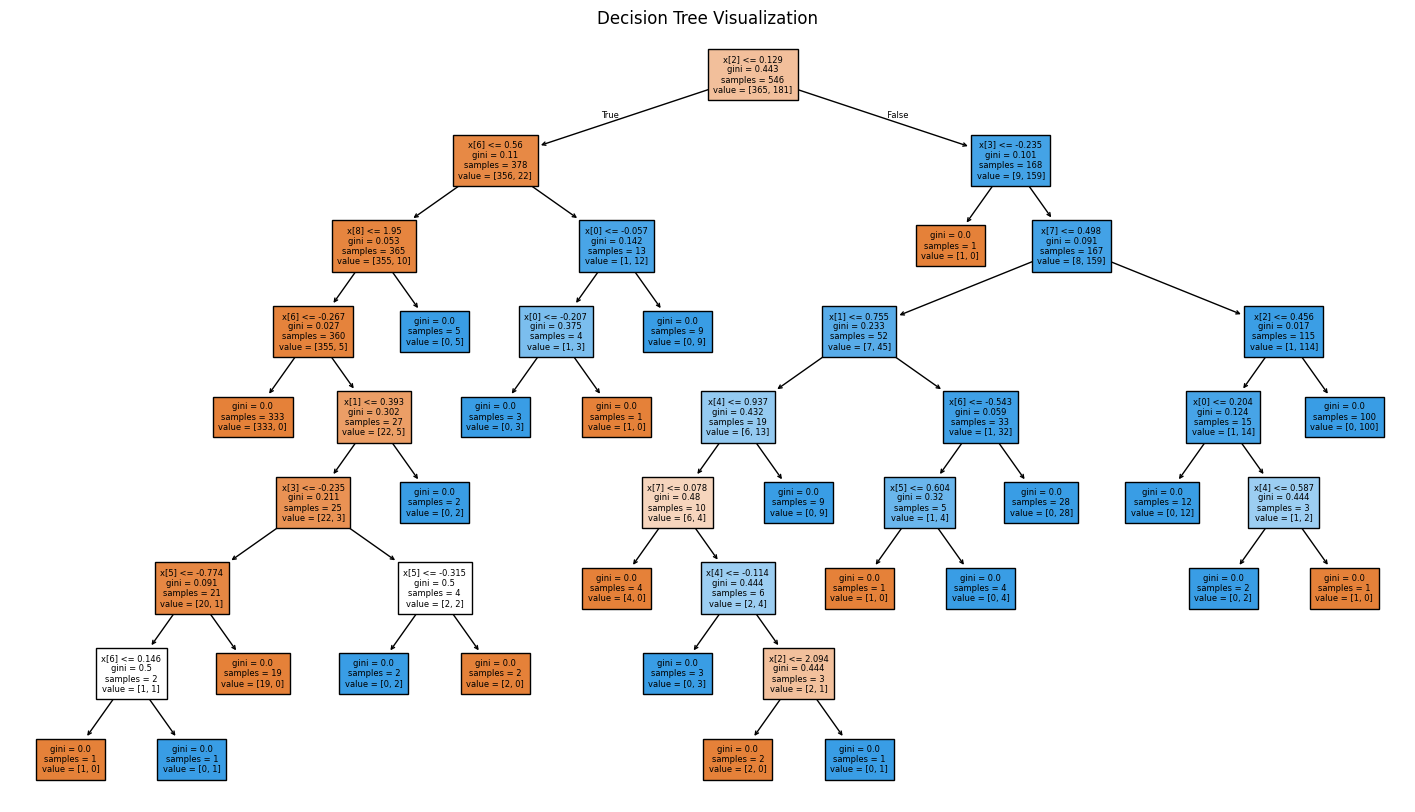


Random Forest Accuracy:
0.9562043795620438

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96        79
           1       0.98      0.91      0.95        58

    accuracy                           0.96       137
   macro avg       0.96      0.95      0.95       137
weighted avg       0.96      0.96      0.96       137


Model Comparison
           Model  Accuracy
0  Decision Tree  0.941606
1  Random Forest  0.956204

Top Features
        Feature  Importance
2     Cell.size    0.263649
3    Cell.shape    0.199185
6   Bare.nuclei    0.160561
7   Bl.cromatin    0.160054
5  Epith.c.size    0.075876


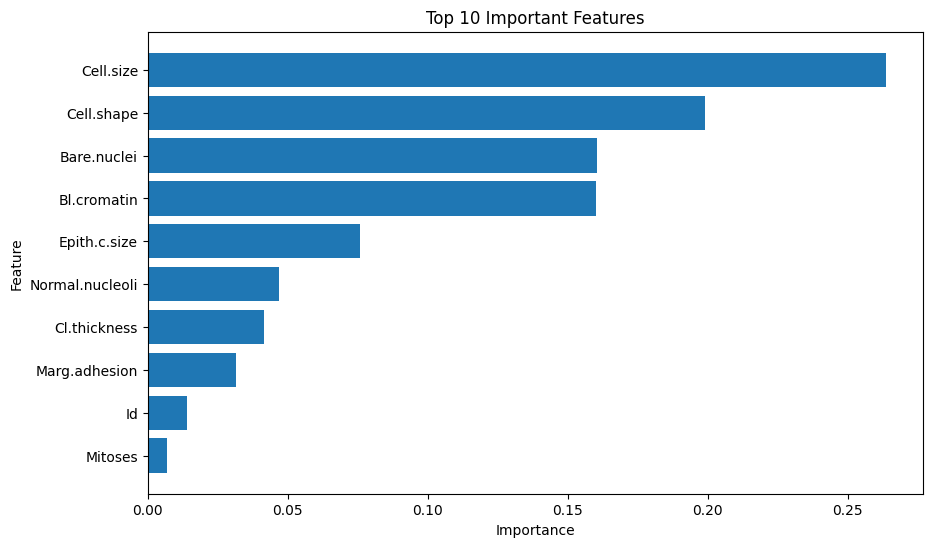

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load Dataset
csv_file_path = '/content/breastcancer.csv'
feature_names = [] # Initialize feature_names to ensure it's always defined

try:
    df = pd.read_csv(csv_file_path)

    # Assuming the last column is the target variable.
    # If your CSV has a specific target column name (e.g., 'diagnosis'),
    # you might need to adjust this line:
    # X = df.drop('diagnosis', axis=1)
    # y = df['diagnosis']
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    # Convert target labels if they are not already numerical (e.g., 'M' and 'B')
    if y.dtype == 'object':
        if 'M' in y.unique() and 'B' in y.unique():
            y = y.map({'B': 0, 'M': 1})
            print("Mapped 'B' to 0 and 'M' to 1 for the target variable.")
        elif len(y.unique()) == 2:
            unique_vals = y.unique()
            y = y.map({unique_vals[0]: 0, unique_vals[1]: 1})
            print(f"Mapped '{unique_vals[0]}' to 0 and '{unique_vals[1]}' to 1 for the target variable.")
        else:
            print("Warning: Target column has object type with more than two unique values or unknown binary labels. "
                  "Please ensure target variable is correctly encoded as 0 and 1.")
            try:
                y = pd.to_numeric(y)
            except ValueError:
                print("Could not convert target column to numeric. Please check the CSV format.")

    # Make sure X has column names for feature importance later
    if X.columns.empty:
        X.columns = [f'feature_{i}' for i in range(X.shape[1])]

    feature_names = X.columns.tolist()

    print(f"Data loaded from {csv_file_path}. Features shape: {X.shape}, Target shape: {y.shape}")

except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found.")
    print("Please ensure the CSV file is uploaded to the Colab environment or the path is correct.")
    # Fallback to the original dataset loading if CSV not found, to allow the rest of the code to run
    print("Falling back to loading default breast cancer dataset for demonstration.")
    data = load_breast_cancer()
    X = pd.DataFrame(data.data, columns=data.feature_names)
    y = data.target
    feature_names = data.feature_names.tolist() # Keep this consistent for later use

print("Dataset Shape:", X.shape)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Decision Tree Classifier
# -----------------------------
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("\nDecision Tree Accuracy:")
print(accuracy_score(y_test, dt_pred))

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

# Visualize Tree
plt.figure(figsize=(18,10))

plot_tree(
    dt_model,
    filled=True,
    fontsize=6
)

plt.title("Decision Tree Visualization")
plt.show()

# -----------------------------
# Random Forest Classifier
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

# -----------------------------
# Compare Performance
# -----------------------------
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_acc, rf_acc]
})

print("\nModel Comparison")
print(comparison)

# -----------------------------
# Feature Importance
# -----------------------------
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Features")
print(feature_importance.head())

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()

plt.show()